<a href="https://colab.research.google.com/github/chanu-24/BMW-CAR-COMPUTER-VISION/blob/main/Day05_ROI_Cropping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 [Day 5] 타겟 강제 추출 및 저장 (ROI Cropping)

✂️ 타겟 #1 잘라내기 완료!


💾 'target_crop_1.jpg' 로컬 저장 완료!

✂️ 타겟 #2 잘라내기 완료!


💾 'target_crop_2.jpg' 로컬 저장 완료!

✂️ 타겟 #3 잘라내기 완료!


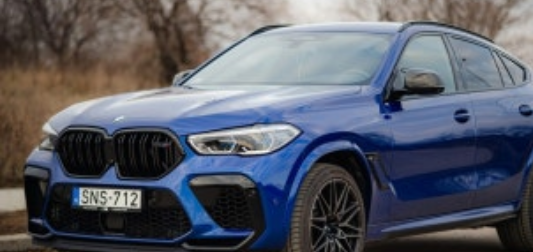

💾 'target_crop_3.jpg' 로컬 저장 완료!

✅ [Day 5 미션 성공] 총 3개의 타겟 데이터를 수집했습니다!


In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print("🚀 [Day 5] 타겟 강제 추출 및 저장 (ROI Cropping)")

file_name = 'my_bmw.jpg'
img = cv2.imread(file_name)

if img is None:
    print("❌ 사진을 다시 업로드해주세요!")
else:
    img = cv2.resize(img, (600, 400))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    # 어제 배운 선 팽창(Dilation)
    kernel = np.ones((3, 3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(thick_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    target_count = 0 # 몇 개나 잘라냈는지 세는 카운터

    for cnt in contours:
        if cv2.contourArea(cnt) < 200: continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h

        if 2.0 <= aspect_ratio <= 5.0:
            target_count += 1

            # ----------------------------------------------------
            # 💡 [오늘의 핵심] 이미지 배열을 좌표만큼 싹둑 자르기!
            # 주의: 파이썬 배열은 [y축(세로), x축(가로)] 순서로 씁니다.
            # ----------------------------------------------------
            cropped_img = img[y:y+h, x:x+w]

            print(f"\n✂️ 타겟 #{target_count} 잘라내기 완료!")
            cv2_imshow(cropped_img) # 잘라낸 부분만 화면에 보여주기

            # 💡 잘라낸 이미지를 새로운 파일로 저장하기!
            save_name = f'target_crop_{target_count}.jpg'
            cv2.imwrite(save_name, cropped_img)
            print(f"💾 '{save_name}' 로컬 저장 완료!")

    if target_count == 0:
        print("\n😅 조건에 맞는 타겟을 찾지 못했습니다. 비율(aspect_ratio) 숫자를 조금 더 조절해보세요!")
    else:
        print(f"\n✅ [Day 5 미션 성공] 총 {target_count}개의 타겟 데이터를 수집했습니다!")


데이터 수집 자동화(ROI Cropping): 전날에 그렸던 초록생 상자안의 이미지만 가위로 싹둑! 잘라내서 컴퓨터터에 저장하는기술

타겟만 싹둑 오려내기

1.이미지는 결국 '액셀표'다.
어제 우리가 구한 초록색 상자의 정보는 가로시작점,세로시작점,너비,높이

우리가 쓸 파이썬에서 이미지는 그저 픽셀 숫자들이 들어있는 거대한 액셀표(배열)일 뿐이다.

따라서 액셀에서 원하는 칸만 드래그해서 복사하듯이, 이미지 배열을 img(어디서부터 어디까지) 이렇게 슬라이싱 해주면 원하는 부분만 완벽하게 잘려나온다,
이것을 전문용어로 ROI(관심영역 추출)이라고 한다,


실패
지금까지 5일동안 썻던 방식은 규칙기반방식
즉,인간이 "번호판은 가로로3배정도 길고,색깔은 이렇고,선명도는 저래야해! 라고 일일이 규칙을 정해주는거다.

하지만 현실은?

1.각도: 차가 삐딱하게 서있으면
2.조명 : 햇빛이 강하거나 밤이되면 색깔과 그림지가 변해서 선이 끊어진다.
3.가림현상: 번호판 앞에 나뭇잎 하나만 가려져 있어도 완벽한 사각형 모양이 깨짐

이 수만가지 변수를 인간이 코드를 다 짜 넣을려면 코드가 수천줄이 넘어가고, 그래도 저렇게 실패하는 경우가 수두룩하다, 실제로 10년전만해도 주차장 차단기 회사 개발자들은 이런문제때문에 밤을 새우먀
임계값을 조절하는 노가다

해결방안?
규칙을 버리고 뇌(CNN)을 만드는것
딥러닝 방식에서는 가로/세로 비율이나 색깔을 우리가 코딩하지 않는다.
대신AI에게 "여기 번호판 사진 1만장이 있다고 ,
이 안에 있는 공통된 특징을 니가 스스로 학습해!라고 명령한다.
